In [1]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# GPR Geopolitical Risk Index : EDA + Preparation

The Caldara and Iacoviello Geopolitical Risk Index measures geopolitical tension from the share of newspaper articles about wars, threats, and conflict. It is the modeling target: the 44 per-country GPRC indices are what the model predicts, while the global series gives context.

**Input:** `data/raw/gpr/data_gpr_export.xls` (Caldara and Iacoviello monthly GPR, 1900 to 2026).
**Output:** `data/interim/gpr/gpr_monthly.csv` (per-country-month target, keyed on ISO3) and `gpr_global_monthly.csv` (global context series).

## 1. Setup

I import the libraries and set the raw and output paths.

In [2]:
import os
import numpy as np
import pandas as pd

RAW = str(ROOT / "data/raw/gpr/data_gpr_export.xls")
OUT_DIR = str(ROOT / "data/interim/gpr")
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#E9E9E9', 'grid.linewidth': 0.8,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, RED = '#1F3864', '#2E75B6', '#C0392B'

GPR is the Caldara and Iacoviello Geopolitical Risk Index, built by counting newspaper articles about geopolitical tensions. I keep a focused set: the global index GPR with its Threats (GPRT) and Acts (GPRA) split for context, plus the 44 GPRC_ country indices that serve as the per-country target. I drop the many unused variants (historical GPRH, NOEW, AND, BASIC, category shares, article counts).

In [ ]:
gpr = pd.read_excel(RAW)
gprc_cols = [c for c in gpr.columns if str(c).startswith('GPRC_')]
print('loaded ->', gpr.shape, '| GPRC_ country columns:', len(gprc_cols))
print('date range:', gpr['month'].min().date(), '-', gpr['month'].max().date())
gpr[['month', 'GPR', 'GPRT', 'GPRA'] + gprc_cols[:20]].head(3)

loaded -> (1516, 115) | GPRC_ country columns: 44
date range: 1900-01-01 - 2026-04-01


,month,GPR,GPRT,GPRA,GPRC_ARG,GPRC_AUS,GPRC_BEL,GPRC_BRA,GPRC_CAN,GPRC_CHE,GPRC_CHL,GPRC_CHN,GPRC_COL,GPRC_DEU,GPRC_DNK,GPRC_EGY,GPRC_ESP,GPRC_FIN,GPRC_FRA,GPRC_GBR,GPRC_HKG,GPRC_HUN,GPRC_IDN,GPRC_IND
0,1900-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1900-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1900-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The workbook holds 1,516 monthly rows back to 1900 and 115 columns, of which 44 are the GPRC_ country indices (the per-country target). The early rows (1900) are NaN, as expected; I keep only 2015 onward in Section 3. GPR, GPRT, and GPRA are the global index and its threats/acts split.

## 2. Data Discovery

GPRT counts Threats (war threats, tensions) and GPRA counts Acts (actual attacks, escalations); GPR combines both. Each GPRC_ column is the same measure computed for one country. I list the 44 GPRC countries and summarize the global GPR over 2015+.

In [5]:
g15 = gpr[gpr['month'] >= '2015-01-01'].copy()
print('GPRC countries (44):', ', '.join(c.replace('GPRC_', '') for c in gprc_cols))
g15[['GPR', 'GPRT', 'GPRA']].describe().round(1)

GPRC countries (44): ARG, AUS, BEL, BRA, CAN, CHE, CHL, CHN, COL, DEU, DNK, EGY, ESP, FIN, FRA, GBR, HKG, HUN, IDN, IND, ISR, ITA, JPN, KOR, MEX, MYS, NLD, NOR, PER, PHL, POL, PRT, RUS, SAU, SWE, THA, TUN, TUR, TWN, UKR, USA, VEN, VNM, ZAF


,GPR,GPRT,GPRA
count,136.0,136.0,136.0
mean,113.8,128.5,101.1
std,41.2,49.7,55.1
min,58.4,64.0,28.5
25%,88.0,95.8,63.3
50%,105.4,120.0,93.2
75%,130.7,142.3,119.7
max,327.0,403.7,445.3


The 44 GPRC countries are the major economies and powers (USA, CHN, RUS, UKR, EU countries...), which is the set the model is trained on. Over 2015+ the global GPR averages 113.8, above the 100 baseline, so this has been a slightly elevated-risk decade, ranging from 58 in calm months to a spike of 327. Threats (GPRT mean 128) run higher than Acts (GPRA mean 101), but Acts are far more volatile (max 445 versus 404), since actual attacks come in sharp bursts.

I confirm the target is complete in the modeling window: I filter to 2015 onward and check that GPR and all 44 GPRC_ columns are fully populated.

In [6]:
print('2015+ rows:', len(g15), '| date range:', g15['month'].min().date(), '-', g15['month'].max().date())
cov = g15[['GPR', 'GPRT', 'GPRA'] + gprc_cols].notna().mean() * 100
print('GPR/GPRT/GPRA coverage %:', cov[['GPR', 'GPRT', 'GPRA']].round(1).to_dict())
print('GPRC_ coverage: min %.1f, max %.1f' % (cov[gprc_cols].min(), cov[gprc_cols].max()))
g15[['month', 'GPR', 'GPRT', 'GPRA']].head(2)

2015+ rows: 136 | date range: 2015-01-01 - 2026-04-01
GPR/GPRT/GPRA coverage %: {'GPR': 100.0, 'GPRT': 100.0, 'GPRA': 100.0}
GPRC_ coverage: min 100.0, max 100.0


,month,GPR,GPRT,GPRA
1380,2015-01-01,111.985695,83.503906,153.339844
1381,2015-02-01,111.924698,118.225204,107.790535


The target is complete: 136 months from January 2015 to April 2026, with GPR, GPRT, GPRA and all 44 GPRC columns at 100% coverage and no gaps.

## 3. Data Preparation

I reshape to long format: one row per country-month for the per-country target (iso3, month, gpr), consistent with the other clean files and ready to join.

In [7]:
gpr_country = (g15.melt(id_vars='month', value_vars=gprc_cols, var_name='iso3', value_name='gpr')
               .assign(iso3=lambda d: d['iso3'].str.replace('GPRC_', '', regex=False))
               .sort_values(['iso3', 'month']).reset_index(drop=True))
gpr_global = g15[['month', 'GPR', 'GPRT', 'GPRA']].sort_values('month').reset_index(drop=True)
print('gpr_country ->', gpr_country.shape, '| countries:', gpr_country['iso3'].nunique(),
      '| months:', gpr_country['month'].min().date(), '-', gpr_country['month'].max().date())
print('gpr_global  ->', gpr_global.shape)
gpr_country.head()

gpr_country -> (5984, 3) | countries: 44 | months: 2015-01-01 - 2026-04-01
gpr_global  -> (136, 4)


,month,iso3,gpr
0,2015-01-01,ARG,0.092139
1,2015-02-01,ARG,0.050173
2,2015-03-01,ARG,0.024715
3,2015-04-01,ARG,0.021256
4,2015-05-01,ARG,0.008551


The reshape gives gpr_country with 5,984 country-months (44 countries x 136 months), keyed on iso3 and month exactly like the other clean files.

## 4. Exploratory Data Analysis

I plot the global GPR over time with the 100 baseline and the three largest spikes annotated, to see the headline geopolitical-risk story of the decade.

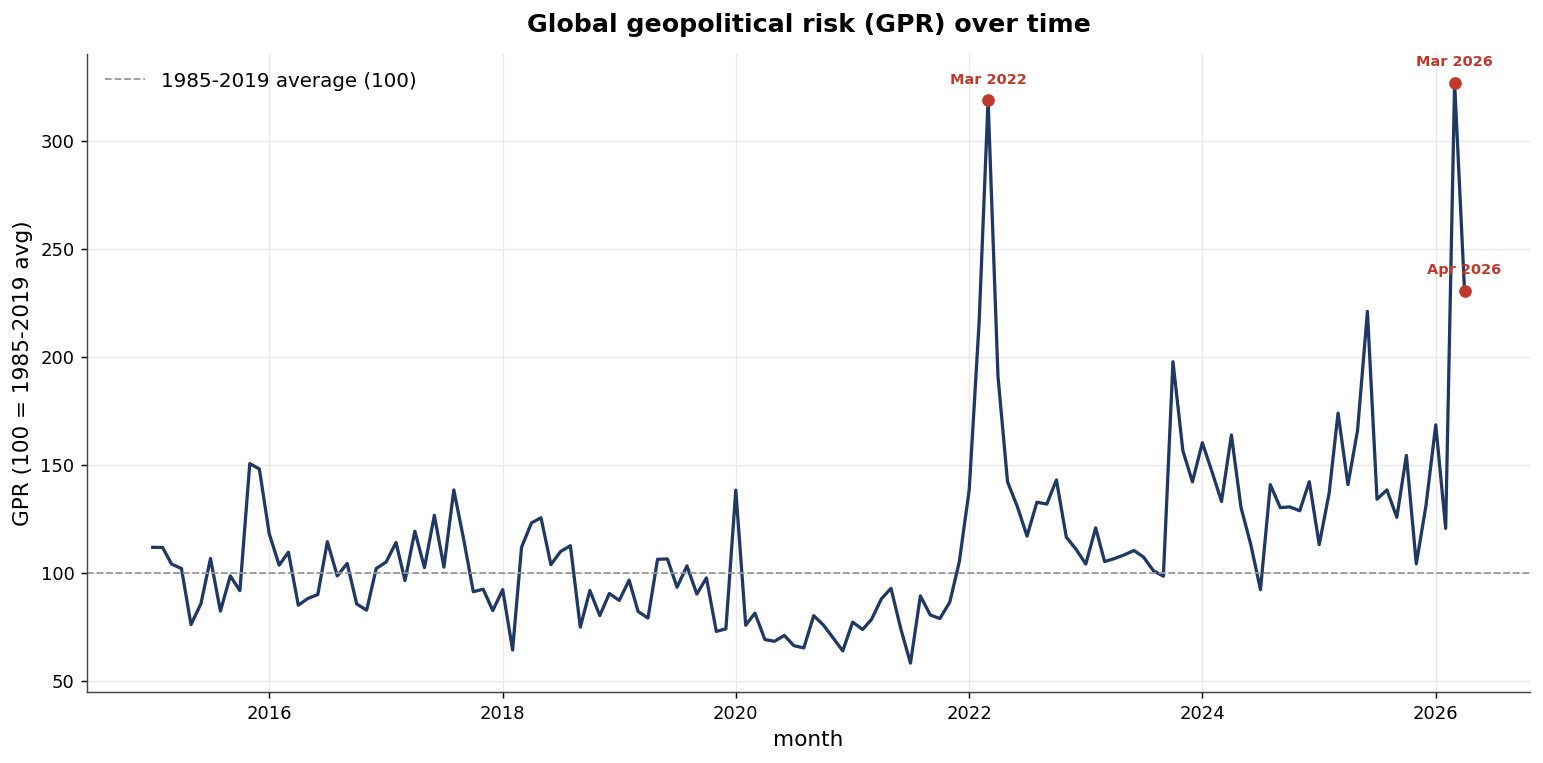

In [8]:
gg = gpr_global
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(gg.month, gg.GPR, color=NAVY, lw=1.8)
ax.axhline(100, color='#999999', ls='--', lw=1, label='1985-2019 average (100)')
top = gg.nlargest(3, 'GPR')
for _, r in top.iterrows():
    ax.scatter(r.month, r.GPR, color=RED, zorder=5)
    ax.annotate(r.month.strftime('%b %Y'), (r.month, r.GPR), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color=RED, fontweight='bold')
ax.set_xlabel('month'); ax.set_ylabel('GPR (100 = 1985-2019 avg)')
ax.set_title('Global geopolitical risk (GPR) over time', pad=12); ax.legend(); fig.tight_layout(); plt.show()

Global risk has run above the 100 baseline for most of the decade and trends sharply upward. The two largest spikes are March 2026 (327), and March 2022 (319, Russia's full-scale invasion of Ukraine).

I rank the 15 countries with the highest mean GPRC over the period, to see who carries the most geopolitical risk.

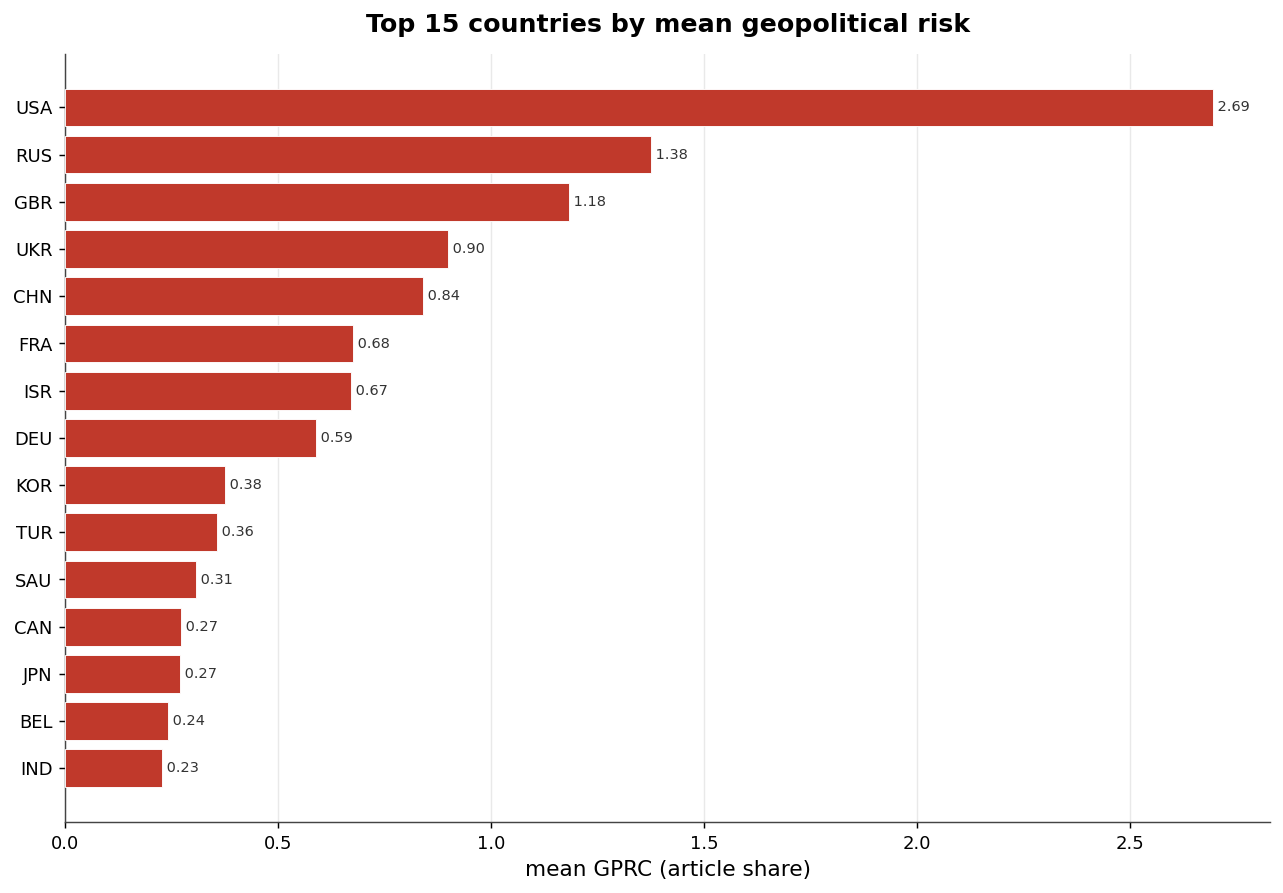

In [9]:
topc = gpr_country.groupby('iso3')['gpr'].mean().nlargest(15)[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(topc.index, topc.values, color=RED, edgecolor='white', linewidth=0.5, zorder=3)
for i, v in enumerate(topc.values):
    ax.text(v, i, f' {v:.2f}', va='center', fontsize=8, color='#333333')
ax.set_xlabel('mean GPRC (article share)'); ax.set_title('Top 15 countries by mean geopolitical risk', pad=12)
ax.grid(axis='y', visible=False); fig.tight_layout(); plt.show()

The USA carries by far the highest mean GPRC (2.69), then Russia (1.38), the UK (1.18), Ukraine (0.90) and China (0.84). This is the defining property of the target: GPR is news-prominence based, so large, militarily and diplomatically central powers dominate it regardless of their internal conditions. It is exactly why structural features (governance, economy) correlate weakly with GPR linearly.

I make the timeline flexible: I can pick GLOBAL (the overall global GPR) or any of the 44 countries for each of two series. When I mix GLOBAL with a country the country goes on a secondary axis, since the scales differ (around 100 versus around 0 to 10).

In [10]:
from ipywidgets import interact, Dropdown, Layout
cty = sorted(gpr_country['iso3'].unique())
opts1 = ['GLOBAL'] + cty
optsN = ['(none)', 'GLOBAL'] + cty
WSTYLE = {'description_width': '110px'}
WIDE = Layout(width='430px')
CCOLORS = [NAVY, RED, '#2E9E5B']

def _raw(s):
    if s == 'GLOBAL':
        return gpr_global.set_index('month')['GPR'].sort_index()
    return gpr_country[gpr_country.iso3 == s].set_index('month')['gpr'].sort_index()

def gpr_timeline(series_1='GLOBAL', series_2='UKR', series_3='ISR'):
    sel = [s for s in [series_1, series_2, series_3] if s != '(none)']
    if not sel:
        print('pick at least one series'); return
    fig, ax = plt.subplots(figsize=(11, 6))
    for s, col in zip(sel, CCOLORS):
        d = _raw(s); d = d / d.max()
        lbl = 'GLOBAL GPR' if s == 'GLOBAL' else f'{s} GPRC'
        ax.plot(d.index, d.values, color=col, lw=1.8, label=lbl)
    ax.set_xlabel('month'); ax.set_ylabel('normalized (each series / its own peak)')
    ax.set_title('Geopolitical risk over time (normalized): ' + ' vs '.join(sel), pad=12)
    ax.legend(fontsize=8); plt.show()

interact(gpr_timeline,
         series_1=Dropdown(options=opts1, value='GLOBAL', description='Series 1', style=WSTYLE, layout=WIDE),
         series_2=Dropdown(options=optsN, value='UKR', description='Series 2', style=WSTYLE, layout=WIDE),
         series_3=Dropdown(options=optsN, value='ISR', description='Series 3', style=WSTYLE, layout=WIDE))

interactive(children=(Dropdown(description='Series 1', layout=Layout(width='430px'), options=('GLOBAL', 'ARG',…

<function __main__.gpr_timeline(series_1='GLOBAL', series_2='UKR', series_3='ISR')>

UKR spikes sharply at the 2022 invasion and pulls global GPR up with it, then decays but stays elevated. ISR stays quiet until late 2023, then spikes repeatedly through 2024-2026. GLOBAL gets affected by both.

## 5. Validate and Save

I check both tables before saving: the per-country target for duplicate iso3-month keys and missing values, and the global table for duplicate months.

In [11]:
print('gpr_country:', gpr_country.shape, '| countries:', gpr_country.iso3.nunique(),
      '| dup iso3-month keys:', int(gpr_country.duplicated(['iso3', 'month']).sum()),
      '| missing:', int(gpr_country['gpr'].isna().sum()))
print('gpr_global :', gpr_global.shape, '| dup months:', int(gpr_global.duplicated(['month']).sum()),
      '| missing:', int(gpr_global[['GPR', 'GPRT', 'GPRA']].isna().sum().sum()))
gpr_country.head()

gpr_country: (5984, 3) | countries: 44 | dup iso3-month keys: 0 | missing: 0
gpr_global : (136, 4) | dup months: 0 | missing: 0


,month,iso3,gpr
0,2015-01-01,ARG,0.092139
1,2015-02-01,ARG,0.050173
2,2015-03-01,ARG,0.024715
3,2015-04-01,ARG,0.021256
4,2015-05-01,ARG,0.008551


I save the tidy per-country target as gpr_monthly.csv (the model's y, keyed on iso3 and month) and the global series as gpr_global_monthly.csv (for context and EDA).

Both tables are clean: gpr_country is 5,984 country-months (44 countries) with no duplicate iso3-month keys and zero missing, and gpr_global is 136 months with no duplicate months and zero missing. The target is complete and ready to join. Note this is a format change from the old clean file: gpr_monthly.csv is now tidy long (iso3, month, gpr) instead of wide, so the master join and the GPR-correlation snippets in the other notebooks must read it as long (no melt).

In [12]:
os.makedirs(OUT_DIR, exist_ok=True)
gpr_country.to_csv(f'{OUT_DIR}/gpr_monthly.csv', index=False)
gpr_global.to_csv(f'{OUT_DIR}/gpr_global_monthly.csv', index=False)
print('saved:', f'{OUT_DIR}/gpr_monthly.csv', gpr_country.shape)
print('saved:', f'{OUT_DIR}/gpr_global_monthly.csv', gpr_global.shape)

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/gpr/gpr_monthly.csv (5984, 3)
saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/gpr/gpr_global_monthly.csv (136, 4)


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.